# Kolmogorov - Smirnov

La prueba de Kolmogorov-Smirnov es una prueba estadística no paramétrica que se utiliza para comparar una muestra con una distribución de referencia (prueba de bondad de ajuste) o para comparar dos muestras entre sí. Esta prueba evalúa si las dos distribuciones son significativamente diferentes.

Kolmogorov-Smirnov propone el siguiente estadístico contraste 

$$ H_0: F(x) = F^*_X(x)  \qquad vs \qquad H_1: F(x) \neq F^*_X(x) $$

Donde $F(x)$ es la función de distribución acumulada (FDA) teórica y desconocida, y $F^*_X(x)$ es la FDA empírica basada en la muestra, la que proponemos con familia de distribución y parámetros completamente especificados.

Para responder a esta hipótesis, se utiliza un resultado clave: 


El Teorema de Glivenko-Cantelli, que establece que la $F(X)$  converge uniformemente a una función empírica $F_n(x)$ cuando el tamaño de la muestra $n$ tiende a infinito.  Es decir:
$$ \sup_x |F_n(x) - F(x)| \xrightarrow[n \to \infty]{} 0 $$


Donde $F_n(x)$ es la función de distribución acumulada empírica basada en una muestra de tamaño $n$, definida como:
$$ F_n(x) = \frac{1}{n} \sum_{i=1}^{n} I_{X_i \leq x} $$


Ejemplo:
Dada una muestra aleatoria de tamaño $n=5$ con los siguientes valores:
$$ X = \{2, 3, 3, 4, 8\} $$
La función de distribución acumulada empírica $F_n(x)$ se calcula como:
| x | 2 | 3 | 4 | 8 |
|---|---|---|---|---|
| F_n(x) | 1/5 | 3/5 | 4/5 | 5/5 | 



Dada una muestra aleatoria de tamaño $n=5$ con los siguientes valores:
$$ X = \{2.1, 3.5, 4.0, 5.2, 6.3\} $$
La función de distribución acumulada empírica $F_n(x)$ se calcula como:

| x | 2.1 | 3.5 | 4.0 | 5.2 | 6.3 |
|---|-----|-----|-----|-----|-----|
| F_n(x) | 1/5 | 2/5 | 3/5 | 4/5 | 1/1 |

Cuando no hay empates, la función de distribución acumulada empírica $F_n(x)$ se puede expresar de manera más compacta como:
$$ F_n(x) =  i / n \quad \text{para } X_{(i)} \leq x < X_{(i+1)}, \quad i = 0, 1, \ldots, n $$





In [24]:
import numpy as np
data = [2, 3, 3, 4, 8]

def empirical(data):
    n = len(data)
    muestra = np.sort(data)
    empirical_values = []
    for x in muestra:
        # Contar los valores menores o iguales a x
        count = muestra <= x
        #print(f'valores menores e igual a {x}: {count}')
        empirical_values.append( np.sum(count) / n) 
    return empirical_values

Muestra1 = [2, 3, 3, 4, 8]
print(empirical(Muestra1))

Muestra2 = [2.1, 3.5, 4.0, 5.2, 6.3]
print(empirical(Muestra2))


[0.2, 0.6, 0.6, 0.8, 1.0]
[0.2, 0.4, 0.6, 0.8, 1.0]


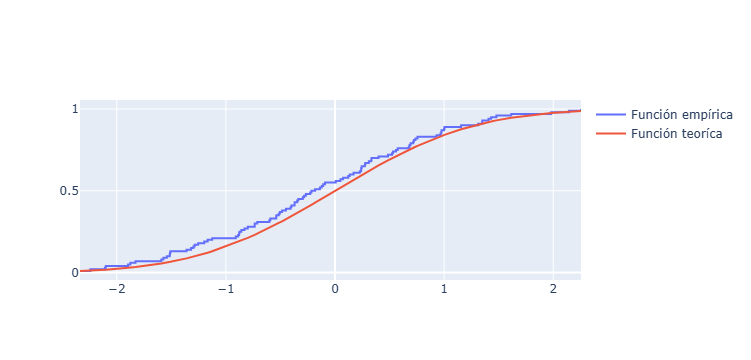

In [64]:
# Demostración visual de Glivenko-Cantelli
import plotly.graph_objects as go
import scipy.stats as stats

# Simulación 
n = 100
media_teorica = 0
desviacion_teorica = 1

# Simular valores aleatorios
x = stats.norm.rvs(loc=media_teorica, scale=desviacion_teorica, size=n) # Generación de la muestra aleatoria
x = np.sort(x) 

F_n = empirical(x) # Función empírica
F_x = stats.norm.cdf(x, loc=media_teorica, scale=desviacion_teorica) #F(x) = P(X <= x)

fig = go.Figure()
fig.add_trace( go.Scatter( x=x, y=F_n, line_shape='hv', name="Función empírica"))
fig.add_trace( go.Scatter( x=x, y=F_x, mode='lines', name="Función teoríca")) 
fig.show()

Kolmogorov-Smirnov define el estadístico de prueba $D_n$ como la máxima diferencia absoluta entre la función de distribución acumulada empírica $F_n(x)$ y la función de distribución acumulada teórica $F(x)$:
$$ D_n = \sup_x |F_X^*(x) - F_n(x)| $$

En su forma más simple, el estadístico $D_n$ se puede calcular como:
$$ D_n = \max (D_n^+, D_n^-) $$
Donde:
- $D_n^+ = \max_{1 \leq i \leq n} \left( abs\left(F_X^*(X_{(i)}) - \frac{i}{n}\right) \right)$
- $D_n^- = \max_{1 \leq i \leq n} \left( abs\left(F_X^*(X_{(i)}) - \frac{i-1}{n}\right) \right)$

In [69]:
n = 1000
# Simular n valores
data = stats.norm.rvs(loc=media_teorica, scale=desviacion_teorica, size=n) # Generación de la muestra aleatoria
print(data[:5])

[-1.67910514 -1.27730353  0.11414857 -0.31321299 -0.76344551]


Dada la anterior muestra que corresponde a rendimientos de una acción. Demuestra que sigue una distrbución normal con media=2, varianza = 1

In [72]:
# Paso 1: Establecer la prueba de hip.


$$H_0: F(X)\sim \text{Normal}(2, 1) \qquad vs \qquad H_a: F(X)\neq \text{Normal}(2, 1)$$

In [103]:
import pandas as pd
# Paso 2: Ordenar la muetsra de menor a mayor
x = np.sort(data)
n = len(x)

# Paso 3: Calcular la función de distribución F_x(X) bajo H0
media_propuesta = 0
desviacion_propuesta = 1
F_x = stats.norm.cdf(x, loc=media_propuesta, scale=desviacion_propuesta) # P(X<x) = F(X)
F_n = empirical(x)

# Paso 3.5: Transformado a tabla
df = pd.DataFrame({'x':x, 'F(x)': F_x, 'Fn(x)':F_n})

# Paso 4: Hacer la función empírica desfasada
df['Fn(x_{i-1})'] = df['Fn(x)'] - 1/n
df

# Paso 5: Calcular D+ y D-
df["Dn_plus"] = abs(df['F(x)'] - df['Fn(x)'])
df["Dn_less"] = abs(df['F(x)'] - df['Fn(x_{i-1})'])

Dn_plus = df["Dn_plus"].max()
Dn_less = df["Dn_less"].max()

print("D+",Dn_plus, "D-", Dn_less)

Dn = max(Dn_plus, Dn_less)
print("Dn", Dn)

D+ 0.015265247456878628 D- 0.01626524745687863
Dn 0.01626524745687863


In [109]:
def kolmogorov(data, media_propuesta=0, desviacion_propuesta=1):
    # Paso 2: Ordenar la muetsra de menor a mayor
    x = np.sort(data)
    n = len(x)
    
    # Paso 3: Calcular la función de distribución F_x(X) bajo H0
    F_x = stats.norm.cdf(x, loc=media_propuesta, scale=desviacion_propuesta) # P(X<x) = F(X)
    F_n = empirical(x)
    
    # Paso 3.5: Transformado a tabla
    df = pd.DataFrame({'x':x, 'F(x)': F_x, 'Fn(x)':F_n})
    
    # Paso 4: Hacer la función empírica desfasada
    df['Fn(x_{i-1})'] = df['Fn(x)'] - 1/n
    df
    
    # Paso 5: Calcular D+ y D-
    df["Dn_plus"] = abs(df['F(x)'] - df['Fn(x)'])
    df["Dn_less"] = abs(df['F(x)'] - df['Fn(x_{i-1})'])
    
    Dn_plus = df["Dn_plus"].max()
    Dn_less = df["Dn_less"].max()
    
    print("D+",Dn_plus, "D-", Dn_less)
    
    Dn = max(Dn_plus, Dn_less)
    print("Dn", Dn)
    print(df)
    return Dn

In [111]:
kolmogorov(data)

D+ 0.015265247456878628 D- 0.01626524745687863
Dn 0.01626524745687863
            x      F(x)  Fn(x)  Fn(x_{i-1})   Dn_plus   Dn_less
0   -3.796489  0.000073  0.001        0.000  0.000927  0.000073
1   -3.057716  0.001115  0.002        0.001  0.000885  0.000115
2   -3.051499  0.001139  0.003        0.002  0.001861  0.000861
3   -2.837184  0.002276  0.004        0.003  0.001724  0.000724
4   -2.769089  0.002811  0.005        0.004  0.002189  0.001189
..        ...       ...    ...          ...       ...       ...
995  2.432695  0.992507  0.996        0.995  0.003493  0.002493
996  2.652452  0.996005  0.997        0.996  0.000995  0.000005
997  2.656800  0.996056  0.998        0.997  0.001944  0.000944
998  2.744145  0.996967  0.999        0.998  0.002033  0.001033
999  3.932562  0.999958  1.000        0.999  0.000042  0.000958

[1000 rows x 6 columns]


0.01626524745687863

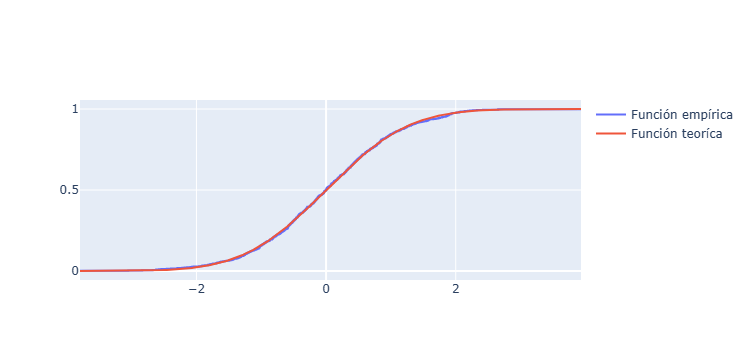

In [105]:

fig = go.Figure()
fig.add_trace( go.Scatter( x=x, y=F_n, line_shape='hv', name="Función empírica"))
fig.add_trace( go.Scatter( x=x, y=F_x, mode='lines', name="Función teoríca")) 
fig.show()

# Regla de decisión

Rechazar $H_0$ si $D_n > W_{n,\alpha}$, donde $W_{n,\alpha}$ es el valor crítico de la distribución de Kolmogorov-Smirnov para un nivel de significancia $\alpha$ dado y tamaño de muestra $n$.
Donde $W_{n,\alpha}$ se puede obtener de tablas estadísticas o mediante software estadístico.



In [121]:
alpha = 0.05 # nivel confianza 95%, 1-alpha
W_critica = stats.kstwobign.ppf((1-alpha) / np.sqrt(n))
W_critica

0.49004324856794884

In [123]:
if Dn > W_critica:
    print("Rechazamos H0: los datos no siguen la distribución propuesta")
else:
    print("No rechazamos H0: los datos siguen la distribución propuesta")

No rechazamos H0: los datos siguen la distribución propuesta


In [139]:
kstest = stats.kstest(data, 'norm', args=(4,1))
Dn = kstest.statistic
p_value = kstest.pvalue
print("Dn", Dn, "pvalue", p_value) # SI p-value < alpha se rechaza H0


Dn 0.9568439317054831 pvalue 0.0


In [137]:
kolmogorov(data, 4,1)

D+ 0.9568439317054831 D- 0.9558439317054831
Dn 0.9568439317054831
            x          F(x)  Fn(x)  Fn(x_{i-1})   Dn_plus       Dn_less
0   -3.796489  3.182662e-15  0.001        0.000  0.001000  3.182662e-15
1   -3.057716  8.463083e-13  0.002        0.001  0.002000  1.000000e-03
2   -3.051499  8.850016e-13  0.003        0.002  0.003000  2.000000e-03
3   -2.837184  4.038258e-12  0.004        0.003  0.004000  3.000000e-03
4   -2.769089  6.479805e-12  0.005        0.004  0.005000  4.000000e-03
..        ...           ...    ...          ...       ...           ...
995  2.432695  5.852169e-02  0.996        0.995  0.937478  9.364783e-01
996  2.652452  8.890184e-02  0.997        0.996  0.908098  9.070982e-01
997  2.656800  8.960362e-02  0.998        0.997  0.908396  9.073964e-01
998  2.744145  1.045843e-01  0.999        0.998  0.894416  8.934157e-01
999  3.932562  4.731165e-01  1.000        0.999  0.526884  5.258835e-01

[1000 rows x 6 columns]


0.9568439317054831